# F1 Strategy Dataset | Pit Stop Prediction

### **Synthetic Dataset Description**
The dataset for this competition (both train and test) was inspired by F1 strategy dataset. Feature distributions are close to, but not exactly the same, as the original, and we intentionally remove Normalized_TyreLife which makes the prediction trivial. Feel free to use the original dataset as part of this competition, both to explore differences as well as to see whether incorporating the original in training improves model performance.

* Files
    * train.csv - the training set, with PitNextLap as target
    * test.csv - the test set, used to predict the likelihood for PitNextLap
    * sample_submission.csv - a sample submission file in the correct format

---

### **Original Dataset Description**

##### Overview
This dataset provides a **lap‑level view of Formula 1 races**, designed for race strategy analysis and machine learning applications.  
It transforms raw telemetry data into a structured format with engineered features that capture **tire degradation, race progression, and driver performance dynamics**.

##### Features Included
- Lap‑by‑lap race data for each driver  
- Tire compound and tire life tracking  
- Lap time and degradation metrics  
- Position changes across laps  
- Race progress indicators  
- Pit stop detection  
- **Target variable:** `PitNextLap` (predict whether a driver will pit next lap)

##### Use Cases
- Predicting pit stop decisions  
- Modeling race strategies  
- Analyzing tire degradation patterns  
- Driver performance and consistency analysis  
- Time‑series and classification tasks  

##### Data Processing
Built using **FastF1** with custom feature engineering:
- Lap time deltas  
- Cumulative degradation  
- Normalized tire life  
- Race progress metrics  

##### Notes
- Aggregated from multiple races (multi‑race dataset)  
- Missing or unreliable entries cleaned  
- Suitable for both beginners and advanced ML workflows  

##### Future Updates
- Additional seasons and races  
- Advanced strategy features (undercut/overcut modeling)  
- Weather and track condition integration  


###### Evaluation: Submissions are evaluated on area under the ROC curve between the predicted probability and the observed target.

In [1]:
# IMPAORT REQUIRED MODULES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import skew, kurtosis, probplot
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
# READING THE DATASETS

train_df = pd.read_csv(r'D:\Codes\Artificial_Intelligence\Machine_Learning\Machine-Learning-With-Scikit-Learn\Projects\Datasets\predicting-f1-pit-stops\Syntetic Dataset\train.csv')

test_df = pd.read_csv(r'D:\Codes\Artificial_Intelligence\Machine_Learning\Machine-Learning-With-Scikit-Learn\Projects\Datasets\predicting-f1-pit-stops\Syntetic Dataset\test.csv')

#train_df_orig = pd.read_csv(r'D:\Codes\Artificial_Intelligence\Machine_Learning\Machine-Learning-With-Scikit-Learn\Projects\Datasets\predicting-f1-pit-stops\Original Dataset\f1_strategy_dataset_v4.csv')

In [3]:
train_df.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [4]:
#train_df_orig.head()

In [5]:
print(f'Syntheic Dataset columns:\n{train_df.columns}\n')
#print(f'Original Dataset columns:\n{train_df_orig.columns}')

Syntheic Dataset columns:
Index(['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber',
       'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'PitNextLap'],
      dtype='object')



There is only one change is the original and synthetic dataset i.e. origial have a Normalized_TyreLife column but in the synthetic it has been removed.

##### Description of the features what do they show or mean:
### F1 Pit Stop Dataset Features Explained
* **Driver**: Name/identifier of the Formula 1 driver for the lap record. Helps group laps by driver and compare performance.
* **Compound**: Type of tire used (Soft, Medium, Hard, etc.). Critical for analyzing tire degradation and pit stop strategy.
* **Race**: The specific race event (e.g., Monaco GP, Italian GP). Useful for multi‑race comparisons and contextual analysis.
* **Year**: The season year of the race. Allows temporal analysis across seasons.
* **PitStop**: Indicates whether a pit stop occurred on that lap. Binary flag (Yes/No) or count of pit stops.
* **LapNumber**: Sequential lap number in the race. Provides time‑series ordering for race progression.
* **Stint**: Segment of laps between pit stops. Shows how long a driver runs on a given tire set.
* **TyreLife**: Number of laps completed on the current tire set. Key metric for tire wear and degradation modeling.
* **Position**: Driver’s race position at the end of the lap. Tracks competitiveness and race dynamics.
* **LapTime (s)**: Recorded lap time in seconds. Core performance measure per lap.
* **LapTime_Delta**: Difference in lap time compared to previous lap. Highlights performance changes, degradation, or improvements.
* **Cumulative_Degradation**: Aggregated measure of tire wear over laps. Useful for modeling tire performance decay.
* **RaceProgress**: Normalized indicator of how far into the race the lap is (e.g., % completed). Helps align laps across different races.
* **Position_Change**: Change in driver’s position compared to the previous lap. Captures overtakes, pit stop impacts, or race incidents.
* **PitNextLap**: **Target variable**: predicts whether the driver will pit on the next lap.Central to the competition’s machine learning task.


In [6]:
train_df.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


In [7]:
#train_df_orig.describe()

### Target Investigation

In [8]:
print(f'Unique value in target = {train_df['PitNextLap'].unique()}')

target_value_count = train_df['PitNextLap'].value_counts().sort_index()
print(f'\nValue count of target = {target_value_count}')

percentage = [count/len(train_df) for count in target_value_count]
print(f'\nPercentage of unique target :\n0.0: {percentage[0]:.2f}%\n1.0: {percentage[1]:.2f}%')

print('The target variable is imbalanced by {percnetage[-1]%}')

Unique value in target = [1. 0.]

Value count of target = PitNextLap
0.0    351759
1.0     87381
Name: count, dtype: int64

Percentage of unique target :
0.0: 0.80%
1.0: 0.20%
The target variable is imbalanced by {percnetage[-1]%}


In [9]:
# SEPARATING THE COLUMNS FOR EASIRE ACCESS

NUMERIC = ['Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change']

CATEGORICAL = ['Driver', 'Compound', 'Race']

TARGET = 'PitNextLap'

In [10]:
for col in CATEGORICAL:
    unq = pd.Series(train_df[col].unique())
    print(f'Number of unique values in column {col}: {len(unq)}\nOccurence count for each value:\n{train_df[col].value_counts()}')
    print('--'*35,'\n')

Number of unique values in column Driver: 887
Occurence count for each value:
Driver
MAS     1682
RAI     1669
BAR     1656
BUT     1655
FIS     1651
        ... 
D669       1
D690       1
D722       1
D672       1
D714       1
Name: count, Length: 887, dtype: int64
---------------------------------------------------------------------- 

Number of unique values in column Compound: 5
Occurence count for each value:
Compound
MEDIUM          211141
HARD            170518
SOFT             38744
INTERMEDIATE     17382
WET               1355
Name: count, dtype: int64
---------------------------------------------------------------------- 

Number of unique values in column Race: 26
Occurence count for each value:
Race
Dutch Grand Prix             24462
Mexico City Grand Prix       23672
Pre-Season Testing           22492
Hungarian Grand Prix         22481
Monaco Grand Prix            21539
Canadian Grand Prix          21416
Austrian Grand Prix          21223
Spanish Grand Prix           20483

## Visualizing the Dataset

In [11]:
# ── Global style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F8F6',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
    'font.size':        11,
})

PALETTE   = {0: '#378ADD', 1: '#E24B4A'}   # 0=no pit, 1=pit next lap
C_BLUE    = '#378ADD'
C_RED     = '#E24B4A'
C_GREEN   = '#1D9E75'
C_AMBER   = '#BA7517'
C_PURPLE  = '#7F77DD'

# TARGET    = 'PitNextLap'
# NUMERIC   = [
#     'LapNumber', 'Stint', 'TyreLife', 'Position',
#     'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
#     'RaceProgress', 'Position_Change'
# ]

Key concern : Class imbalance (~20% positive class)

#### 1. Visualization of Target - Analytics and Treads

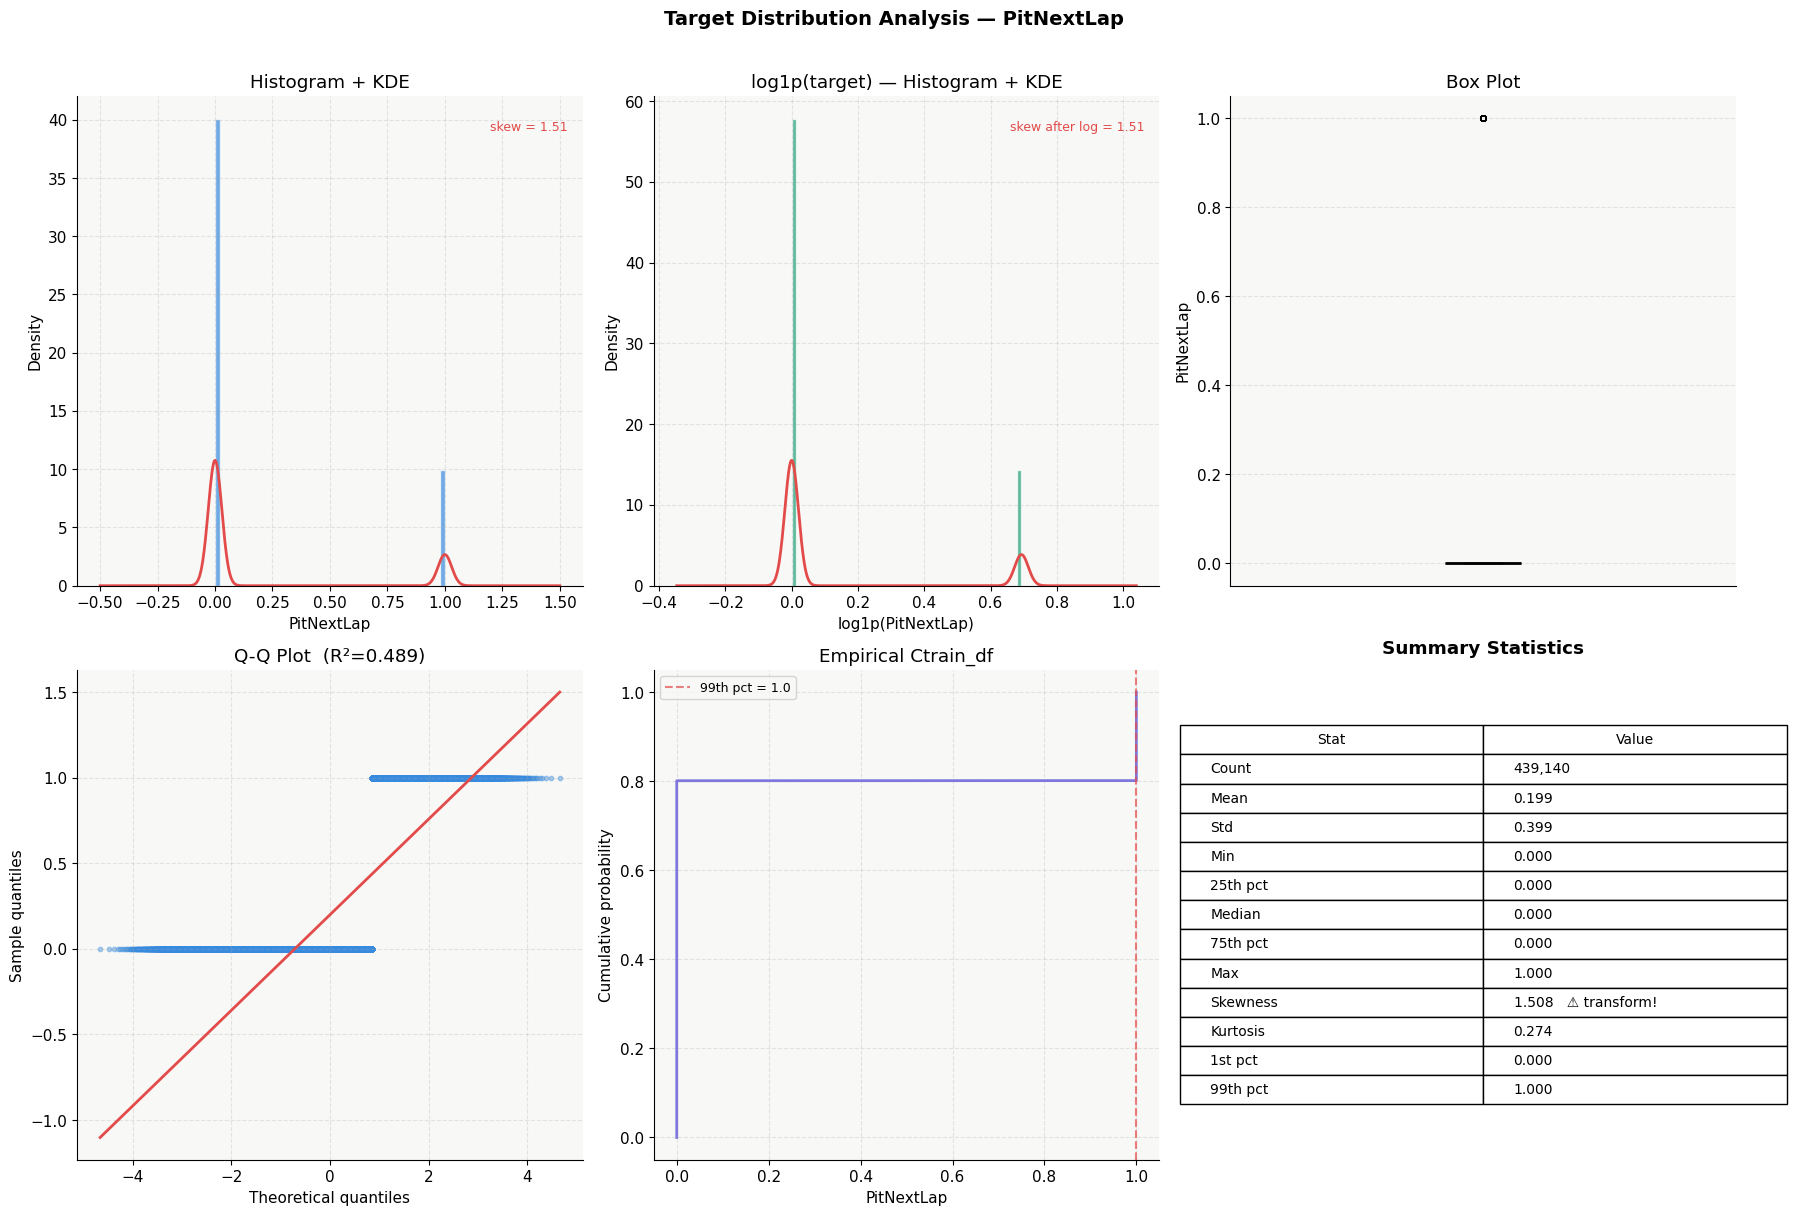


── Target: PitNextLap ──
  Skewness        : 1.51
  Recommendation  : → Use log1p(target). Predict log, then np.expm1() back.
  Kurtosis        : 0.27  
  Outlier cap     : clip values above 1.00 (99th pct) if needed


In [12]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle(f'Target Distribution Analysis — {TARGET}', fontsize=14, fontweight='bold', y=1.01)

# ── 1. Histogram + KDE ───────────────────────────────────────────────────────
# WHY: Shows the overall shape — normal, skewed, bimodal.
# LOOK FOR: Long right tail → log-transform. Two humps → maybe two sub-populations.
ax1 = fig.add_subplot(2, 3, 1)
ax1.hist(train_df[TARGET], bins=50, color='#378ADD', alpha=0.7, density=True, edgecolor='white')
train_df[TARGET].plot.kde(ax=ax1, color='#E24B4A', linewidth=2)
ax1.set_title('Histogram + KDE')
ax1.set_xlabel(TARGET)
sk = skew(train_df[TARGET].dropna())
ax1.text(0.97, 0.95, f'skew = {sk:.2f}', transform=ax1.transAxes,
         ha='right', va='top', fontsize=9,
         color='#E24B4A' if abs(sk) > 1 else 'black')


# ── 2. Log-transformed histogram (only if skewed) ────────────────────────────
# WHY: If skew > 1, predicting log(y) and exponentiating back gives much
#      better RMSE. This plot confirms whether the log makes it normal.
# LOOK FOR: Bell-shaped curve after transform → log is the right move.
ax2 = fig.add_subplot(2, 3, 2)
log_vals = np.log1p(train_df[TARGET].clip(lower=0).dropna())
ax2.hist(log_vals, bins=50, color='#1D9E75', alpha=0.7, density=True, edgecolor='white')
log_vals.plot.kde(ax=ax2, color='#E24B4A', linewidth=2)
sk_log = skew(log_vals)
ax2.set_title('log1p(target) — Histogram + KDE')
ax2.set_xlabel(f'log1p({TARGET})')
ax2.text(0.97, 0.95, f'skew after log = {sk_log:.2f}', transform=ax2.transAxes,
         ha='right', va='top', fontsize=9,
         color='#1D9E75' if abs(sk_log) < 0.5 else '#E24B4A')

# ── 3. Box plot ───────────────────────────────────────────────────────────────
# WHY: Shows median, IQR, and outlier points clearly.
# LOOK FOR: Many dots beyond whiskers → outliers exist.
#           Very long upper whisker → right skew confirmed.
ax3 = fig.add_subplot(2, 3, 3)
ax3.boxplot(train_df[TARGET].dropna(), vert=True, patch_artist=True,
            boxprops=dict(facecolor='#378ADD', alpha=0.6),
            medianprops=dict(color='black', linewidth=2),
            flierprops=dict(marker='o', color='#E24B4A', alpha=0.4, markersize=4))
ax3.set_title('Box Plot')
ax3.set_ylabel(TARGET)
ax3.set_xticks([])

# ── 4. Q-Q plot ───────────────────────────────────────────────────────────────
# WHY: Checks if the target is truly normally distributed.
#      If the dots follow the diagonal line → it's normal.
#      Points curving away at the ends → skewed or heavy tails.
# LOOK FOR: S-curve → bimodal. Curve up at top → right skew.
ax4 = fig.add_subplot(2, 3, 4)
(osm, osr), (slope, intercept, r) = probplot(train_df[TARGET].dropna(), dist='norm')
ax4.scatter(osm, osr, color='#378ADD', alpha=0.4, s=10)
ax4.plot(osm, slope * np.array(osm) + intercept, color='#E24B4A', linewidth=2)
ax4.set_title(f'Q-Q Plot  (R²={r**2:.3f})')
ax4.set_xlabel('Theoretical quantiles')
ax4.set_ylabel('Sample quantiles')

# ── 5. Empirical Ctrain_df ──────────────────────────────────────────────────────────
# WHY: Shows what % of your data falls below any given value.
#      Useful for deciding where to cap outliers (e.g. 99th percentile).
# LOOK FOR: Very steep rise early then flat tail → most values are small,
#           a few extreme values stretch the range.
ax5 = fig.add_subplot(2, 3, 5)
sorted_vals = np.sort(train_df[TARGET].dropna())
ctrain_df = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
ax5.plot(sorted_vals, ctrain_df, color='#7F77DD', linewidth=2)
p99 = np.percentile(sorted_vals, 99)
ax5.axvline(p99, color='#E24B4A', linestyle='--', alpha=0.7, label=f'99th pct = {p99:.1f}')
ax5.set_title('Empirical Ctrain_df')
ax5.set_xlabel(TARGET)
ax5.set_ylabel('Cumulative probability')
ax5.legend(fontsize=9)

# ── 6. Summary stats panel ────────────────────────────────────────────────────
# WHY: Hard numbers to complement the visuals.
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
stats = train_df[TARGET].describe()
kurt  = kurtosis(train_df[TARGET].dropna())
p1    = train_df[TARGET].quantile(0.01)
p99_v = train_df[TARGET].quantile(0.99)
table_data = [
    ['Count',     f"{stats['count']:,.0f}"],
    ['Mean',      f"{stats['mean']:.3f}"],
    ['Std',       f"{stats['std']:.3f}"],
    ['Min',       f"{stats['min']:.3f}"],
    ['25th pct',  f"{stats['25%']:.3f}"],
    ['Median',    f"{stats['50%']:.3f}"],
    ['75th pct',  f"{stats['75%']:.3f}"],
    ['Max',       f"{stats['max']:.3f}"],
    ['Skewness',  f"{sk:.3f}   {'⚠ transform!' if abs(sk)>1 else '✓ ok'}"],
    ['Kurtosis',  f"{kurt:.3f}"],
    ['1st pct',   f"{p1:.3f}"],
    ['99th pct',  f"{p99_v:.3f}"],
]
tbl = ax6.table(cellText=table_data, colLabels=['Stat', 'Value'],
                loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.5)
ax6.set_title('Summary Statistics', fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

# ── Decision helper ───────────────────────────────────────────────────────────
print(f"\n── Target: {TARGET} ──")
print(f"  Skewness        : {sk:.2f}")
print(f"  Recommendation  : {'→ Use log1p(target). Predict log, then np.expm1() back.' if abs(sk) > 1 else '→ Target looks normal. Predict as-is.'}")
print(f"  Kurtosis        : {kurt:.2f}  {'(heavy tails — check outliers)' if kurt > 3 else ''}")
print(f"  Outlier cap     : clip values above {p99_v:.2f} (99th pct) if needed")

The one rule — if skewness > 1, add this before training and after predicting:
#### Before training
y_train_log = np.log1p(y_train)

model.fit(X_train, y_train_log)

#### After predicting
y_pred = np.expm1(model.predict(X_test))

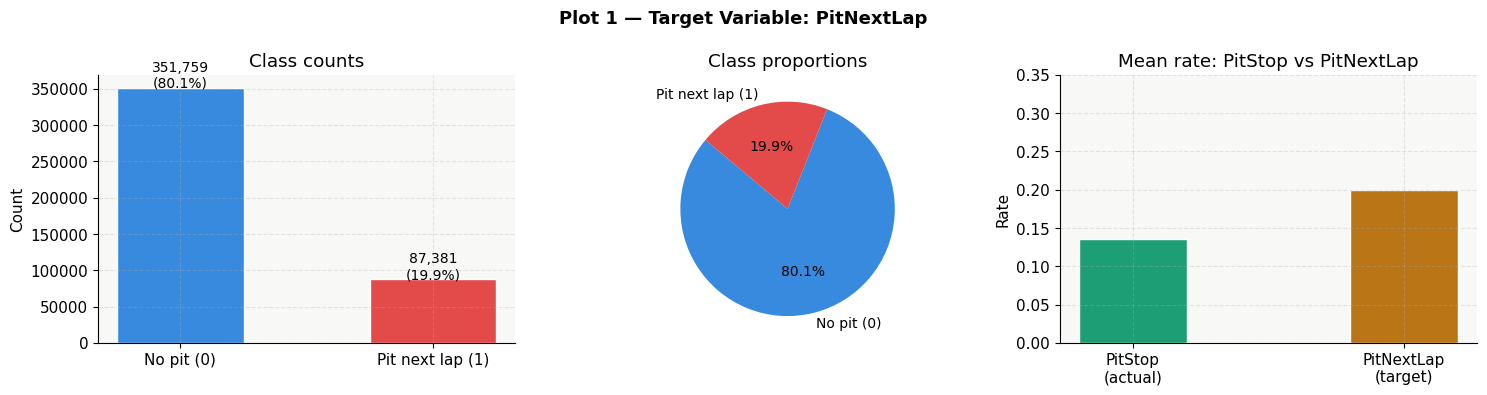

In [13]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  PLOT 1 — Target distribution (PitNextLap)                  ║
# ╚══════════════════════════════════════════════════════════════╝
"""
WHY:
  PitNextLap is binary. You need to know the exact imbalance
  ratio before choosing a model strategy. With ~20% positive,
  a naive model that always predicts 0 gets 80% accuracy —
  which is completely useless. This plot makes that visible.

WHAT TO LOOK FOR:
  - If positive class < 15%  → use class_weight='balanced',
    SMOTE, or adjust decision threshold
  - 20% positive (this dataset) → manageable but use F1-score
    and ROC-AUC, NOT accuracy, as your evaluation metric
  - Check PitStop (actual pit) vs PitNextLap (next-lap flag) —
    their counts should be close; a big gap = labeling issue

WHAT TO DO AFTER:
  → Use: model = XGBClassifier(scale_pos_weight=4)
         or    RandomForest(class_weight='balanced')
  → Use F1-score (macro), ROC-AUC, PR-AUC as metrics
  → Set decision threshold by Precision-Recall curve, not 0.5
"""
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Plot 1 — Target Variable: PitNextLap', fontsize=13, fontweight='bold')

# Bar chart
counts = train_df[TARGET].value_counts().sort_index()
labels = ['No pit (0)', 'Pit next lap (1)']
axes[0].bar(labels, counts, color=[C_BLUE, C_RED], width=0.5, edgecolor='white')
for i, (lbl, n) in enumerate(zip(labels, counts)):
    axes[0].text(i, n + 500, f'{n:,}\n({n/len(train_df)*100:.1f}%)',
                 ha='center', fontsize=10)
axes[0].set_title('Class counts')
axes[0].set_ylabel('Count')

# Pie
axes[1].pie(counts, labels=labels, colors=[C_BLUE, C_RED],
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 10})
axes[1].set_title('Class proportions')

# Compare PitStop vs PitNextLap
axes[2].bar(['PitStop\n(actual)', 'PitNextLap\n(target)'],
            [train_df['PitStop'].mean(), train_df['PitNextLap'].mean()],
            color=[C_GREEN, C_AMBER], width=0.4, edgecolor='white')
axes[2].set_title('Mean rate: PitStop vs PitNextLap')
axes[2].set_ylabel('Rate')
axes[2].set_ylim(0, 0.35)

plt.tight_layout()
plt.show()

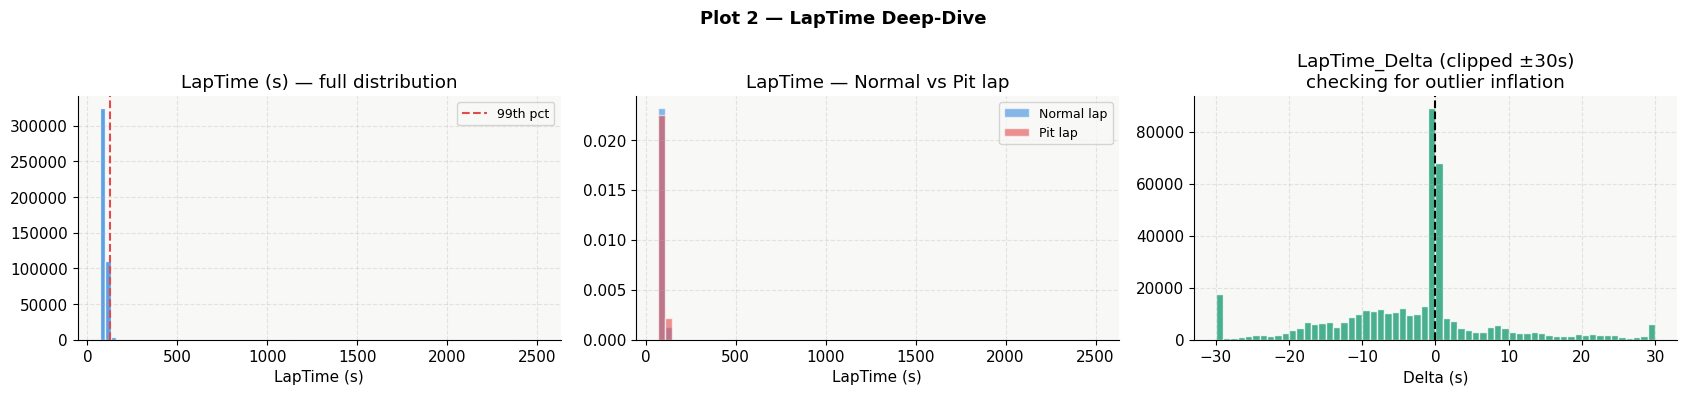

In [14]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  PLOT 2 — LapTime deep-dive (the most important feature)    ║
# ╚══════════════════════════════════════════════════════════════╝
"""
WHY:
  LapTime std = 19.77s is extremely high for F1 (normal variation
  is ~0.3–1s per lap). This means outlier laps (safety cars,
  pit in-laps, VSC) are massively inflating the std.
  If you feed raw LapTime to a model, those outlier laps will
  dominate training and destroy signal.

WHAT TO LOOK FOR:
  - Main distribution peak around 80–100s (clean laps)
  - Secondary peak or long tail at 120–150s+ (pit laps / SC laps)
  - In-lap before pitting is always much slower → LapTime on the
    lap BEFORE PitNextLap=1 should be roughly normal
  - The lap WHERE PitStop=1 will have massively elevated LapTime

WHAT TO DO AFTER:
  → Create flag: train_df['is_slow_lap'] = (train_df['LapTime (s)'] > threshold)
  → Remove or cap pit in-laps when analyzing degradation
  → Consider LapTime_Delta instead of raw LapTime as a feature
    (it normalises out circuit length differences)
"""
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('Plot 2 — LapTime Deep-Dive', fontsize=13, fontweight='bold')

# Full distribution
axes[0].hist(train_df['LapTime (s)'], bins=80, color=C_BLUE, alpha=0.8, edgecolor='white')
axes[0].set_title('LapTime (s) — full distribution')
axes[0].set_xlabel('LapTime (s)')
axes[0].axvline(train_df['LapTime (s)'].quantile(0.99), color=C_RED,
                linestyle='--', label='99th pct')
axes[0].legend(fontsize=9)

# Split by PitStop (pit laps vs normal laps)
for val, lbl, color in [(0, 'Normal lap', C_BLUE), (1, 'Pit lap', C_RED)]:
    axes[1].hist(train_df[train_df['PitStop'] == val]['LapTime (s)'],
                 bins=60, alpha=0.6, label=lbl, color=color,
                 edgecolor='white', density=True)
axes[1].set_title('LapTime — Normal vs Pit lap')
axes[1].set_xlabel('LapTime (s)')
axes[1].legend(fontsize=9)

# LapTime_Delta distribution (should be centered near 0)
axes[2].hist(train_df['LapTime_Delta'].clip(-30, 30), bins=60,
             color=C_GREEN, alpha=0.8, edgecolor='white')
axes[2].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[2].set_title('LapTime_Delta (clipped ±30s)\nchecking for outlier inflation')
axes[2].set_xlabel('Delta (s)')

plt.tight_layout()
plt.show()

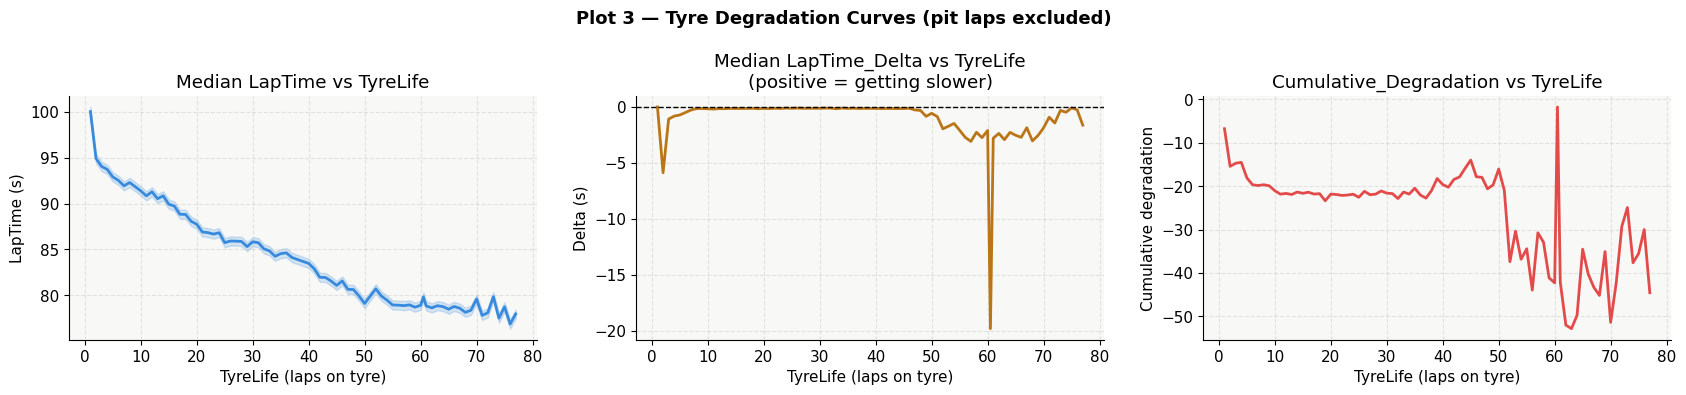

In [15]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  PLOT 3 — Tyre degradation curve (the heart of the problem) ║
# ╚══════════════════════════════════════════════════════════════╝
"""
WHY:
  This is THE key domain relationship in F1 strategy: as tyres
  age (TyreLife increases), lap times get slower. But this
  degradation is NON-LINEAR — fast early degradation, then a
  plateau, then a cliff. A linear model will miss this entirely.

WHAT TO LOOK FOR:
  - LapTime rising with TyreLife → confirm degradation exists
  - Shape of the curve: linear? exponential? cliff at TyreLife ~25?
  - LapTime_Delta getting more positive as TyreLife increases
    → each lap is slower than the previous (degrading)
  - Cumulative_Degradation should become more negative or more
    positive consistently with TyreLife (check direction)

WHAT TO DO AFTER:
  → Add polynomial feature: train_df['TyreLife_sq'] = train_df['TyreLife']**2
  → Add: train_df['TyreLife_log'] = np.log1p(train_df['TyreLife'])
  → These capture the non-linear degradation cliff
  → XGBoost / LightGBM handle this naturally via tree splits
"""
# Exclude pit laps for clean degradation signal
clean = train_df[(train_df['PitStop'] == 0) & (train_df['LapTime (s)'] < 130)].copy()
deg   = clean.groupby('TyreLife')[['LapTime (s)', 'LapTime_Delta',
                                    'Cumulative_Degradation']].median()

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('Plot 3 — Tyre Degradation Curves (pit laps excluded)', fontsize=13, fontweight='bold')

axes[0].plot(deg.index, deg['LapTime (s)'], color=C_BLUE, linewidth=2)
axes[0].fill_between(deg.index, deg['LapTime (s)'] - 0.5,
                     deg['LapTime (s)'] + 0.5, alpha=0.2, color=C_BLUE)
axes[0].set_title('Median LapTime vs TyreLife')
axes[0].set_xlabel('TyreLife (laps on tyre)')
axes[0].set_ylabel('LapTime (s)')

axes[1].plot(deg.index, deg['LapTime_Delta'], color=C_AMBER, linewidth=2)
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('Median LapTime_Delta vs TyreLife\n(positive = getting slower)')
axes[1].set_xlabel('TyreLife (laps on tyre)')
axes[1].set_ylabel('Delta (s)')

axes[2].plot(deg.index, deg['Cumulative_Degradation'], color=C_RED, linewidth=2)
axes[2].set_title('Cumulative_Degradation vs TyreLife')
axes[2].set_xlabel('TyreLife (laps on tyre)')
axes[2].set_ylabel('Cumulative degradation')

plt.tight_layout()
plt.show()

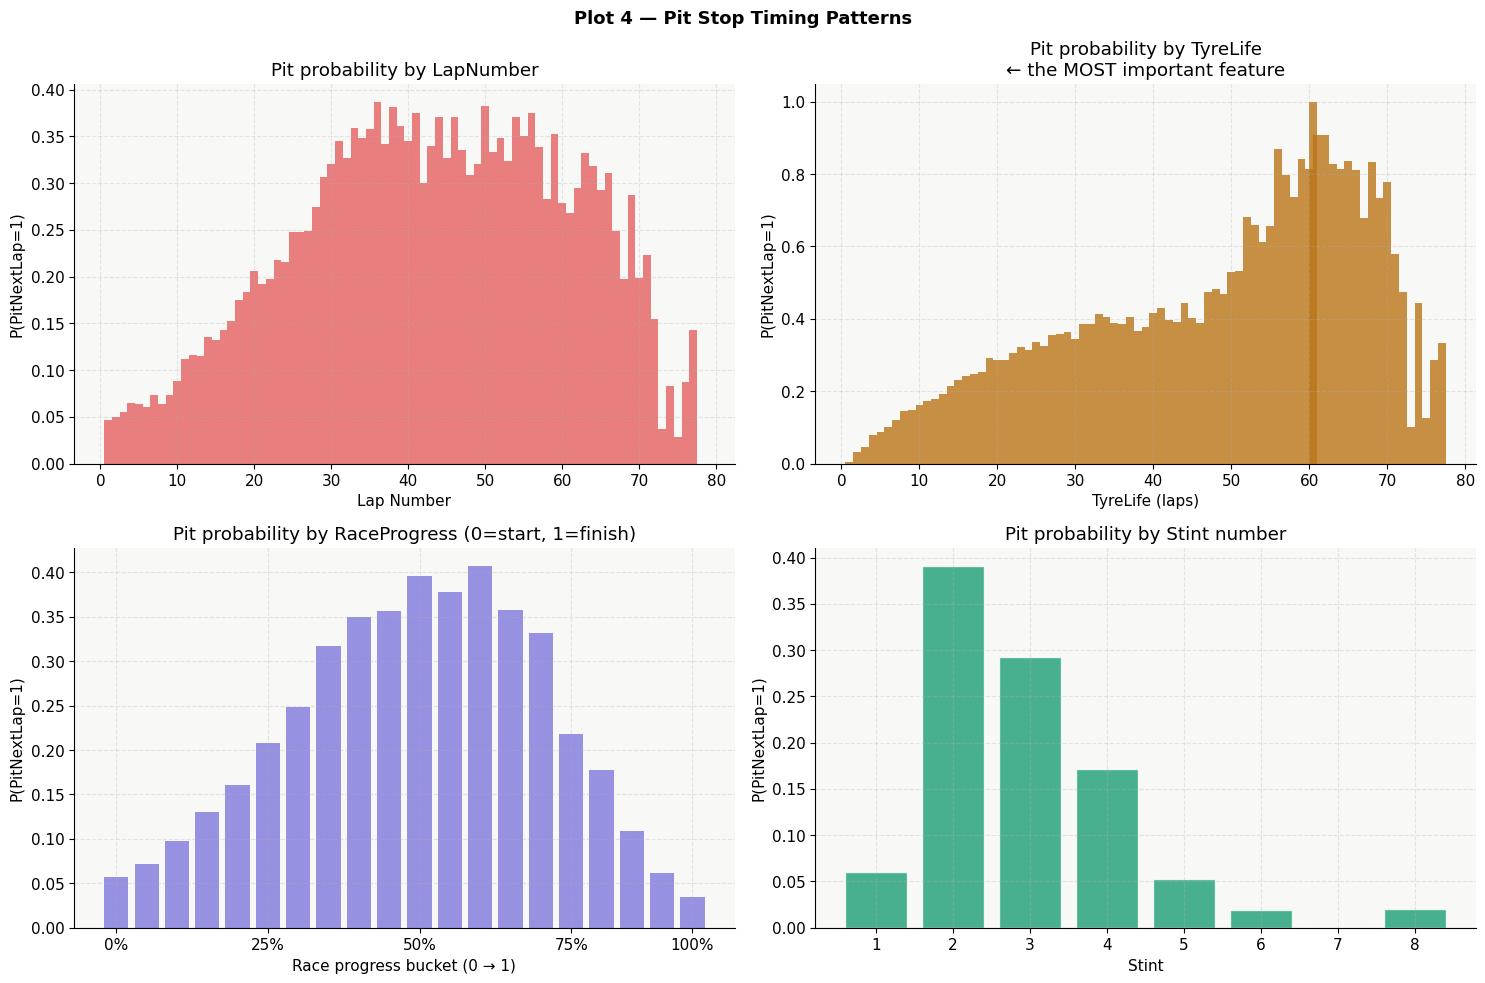

In [16]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  PLOT 4 — When do drivers pit? (pit timing patterns)        ║
# ╚══════════════════════════════════════════════════════════════╝
"""
WHY:
  If PitNextLap=1 clusters around specific LapNumbers or
  TyreLife values, those are your strongest features. This
  directly tells you what the model needs to learn.

WHAT TO LOOK FOR:
  - LapNumber: pits tend to cluster around laps 15–20, 35–40
    (one-stop strategy windows)
  - TyreLife: pit probability should spike at TyreLife ~20–30
    (when tyres are worn out)
  - RaceProgress: if pits cluster at 0.3–0.4 and 0.6–0.7 →
    typical two-stop strategy shape
  - Sharp spikes at specific laps = strategic decisions
  - Flat line = random/reactive pitting (harder to predict)

WHAT TO DO AFTER:
  → TyreLife and RaceProgress are likely your top-2 features
  → Create: train_df['pit_window'] = train_df['RaceProgress'].between(0.3, 0.5)
  → Create: train_df['tyre_critical'] = (train_df['TyreLife'] > 25).astype(int)
"""
pit_laps = train_df[train_df[TARGET] == 1]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Plot 4 — Pit Stop Timing Patterns', fontsize=13, fontweight='bold')

# Pit rate by LapNumber
pit_by_lap = train_df.groupby('LapNumber')[TARGET].mean()
axes[0, 0].bar(pit_by_lap.index, pit_by_lap.values,
               color=C_RED, alpha=0.7, width=1.0, edgecolor='none')
axes[0, 0].set_title('Pit probability by LapNumber')
axes[0, 0].set_xlabel('Lap Number')
axes[0, 0].set_ylabel('P(PitNextLap=1)')

# Pit rate by TyreLife
pit_by_tyre = train_df.groupby('TyreLife')[TARGET].mean()
axes[0, 1].bar(pit_by_tyre.index, pit_by_tyre.values,
               color=C_AMBER, alpha=0.8, width=1.0, edgecolor='none')
axes[0, 1].set_title('Pit probability by TyreLife\n← the MOST important feature')
axes[0, 1].set_xlabel('TyreLife (laps)')
axes[0, 1].set_ylabel('P(PitNextLap=1)')

# Pit rate by RaceProgress bucket
train_df['progress_bin'] = pd.cut(train_df['RaceProgress'], bins=20)
pit_by_prog = train_df.groupby('progress_bin', observed=True)[TARGET].mean()
axes[1, 0].bar(range(len(pit_by_prog)), pit_by_prog.values,
               color=C_PURPLE, alpha=0.8, edgecolor='none')
axes[1, 0].set_title('Pit probability by RaceProgress (0=start, 1=finish)')
axes[1, 0].set_xlabel('Race progress bucket (0 → 1)')
axes[1, 0].set_ylabel('P(PitNextLap=1)')
axes[1, 0].set_xticks([0, 5, 10, 15, 19])
axes[1, 0].set_xticklabels(['0%', '25%', '50%', '75%', '100%'])

# Pit rate by Stint
pit_by_stint = train_df.groupby('Stint')[TARGET].mean()
axes[1, 1].bar(pit_by_stint.index, pit_by_stint.values,
               color=C_GREEN, alpha=0.8, edgecolor='white')
axes[1, 1].set_title('Pit probability by Stint number')
axes[1, 1].set_xlabel('Stint')
axes[1, 1].set_ylabel('P(PitNextLap=1)')

plt.tight_layout()
plt.show()

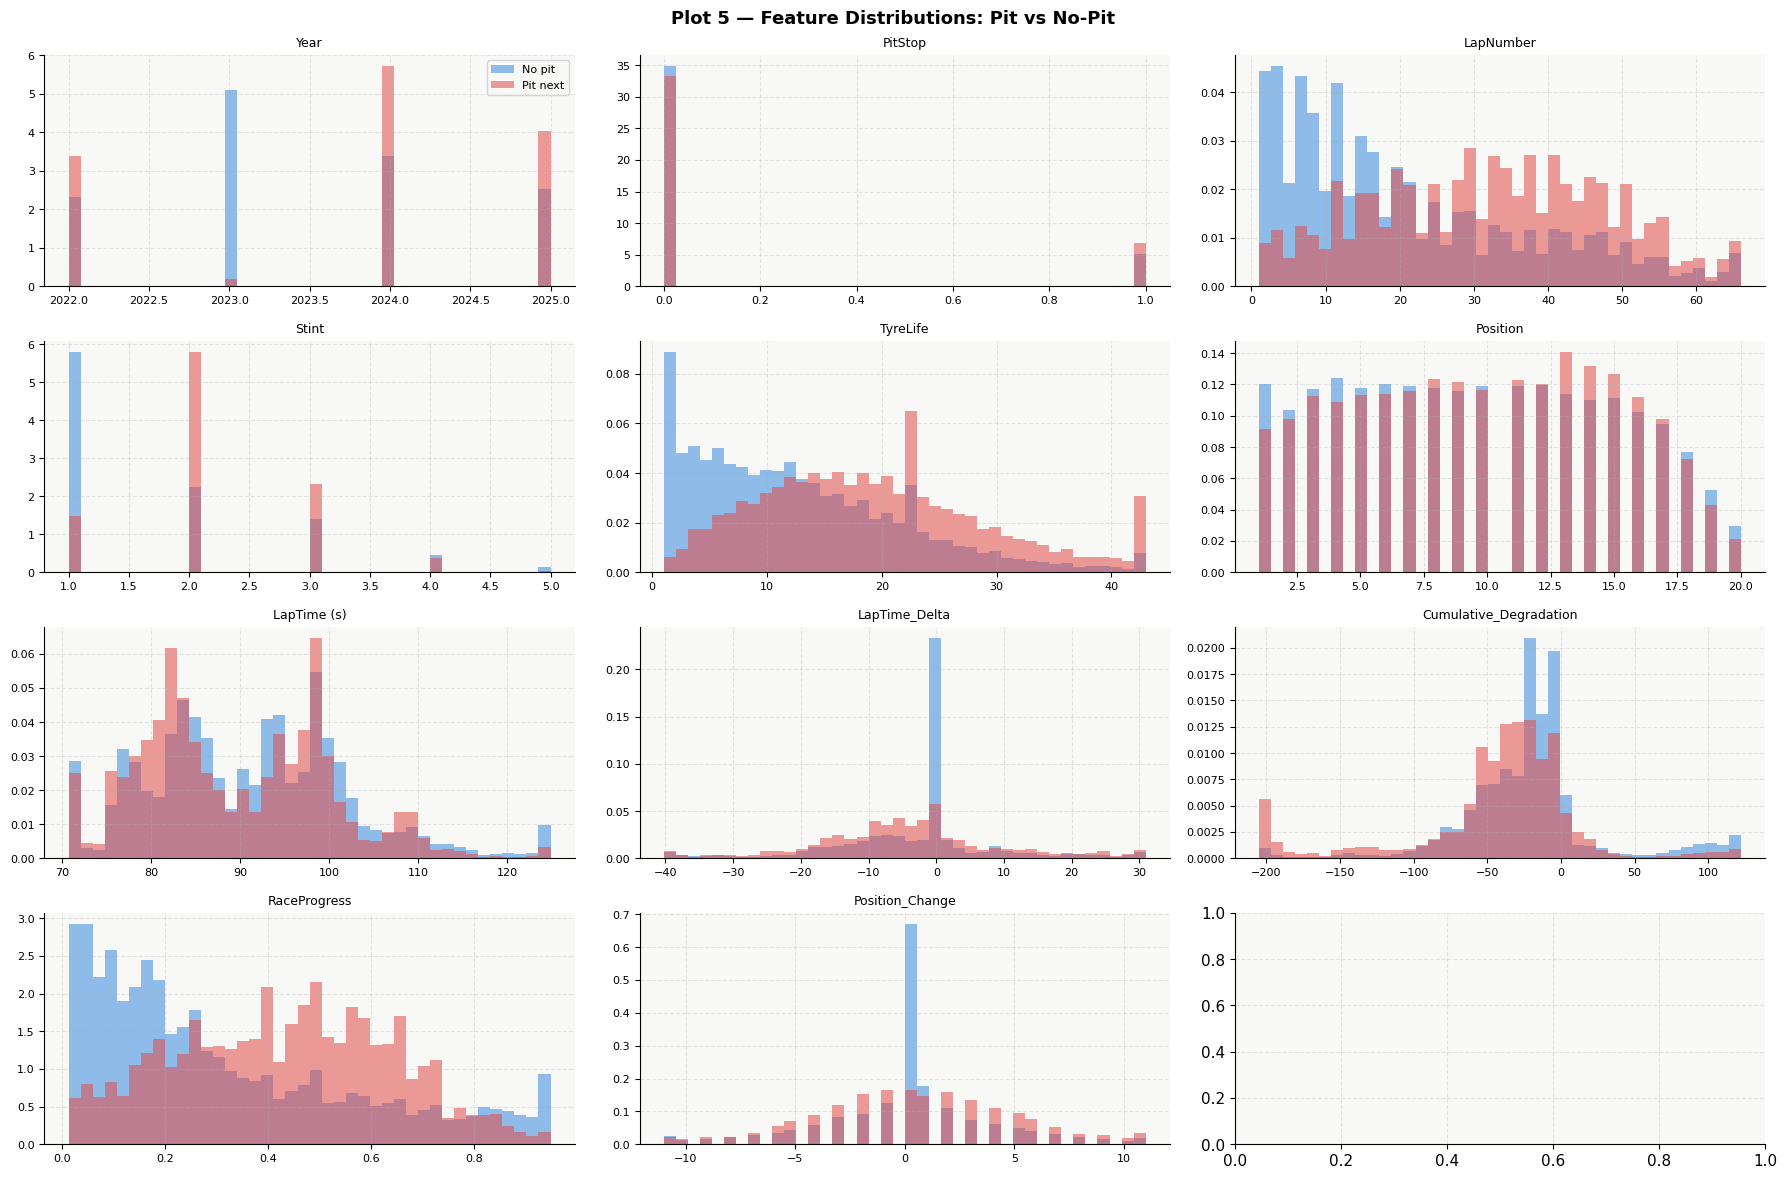

In [17]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  PLOT 5 — Feature distributions colored by PitNextLap       ║
# ╚══════════════════════════════════════════════════════════════╝
"""
WHY:
  Most important classification plot. When the two colored
  distributions (pit vs no-pit) are well separated for a feature,
  that feature is highly predictive of the target.

WHAT TO LOOK FOR:
  - TyreLife: pit=1 distribution should be shifted RIGHT
    (drivers pit on older tyres — higher TyreLife)
  - Cumulative_Degradation: should differ between classes
  - RaceProgress: pit=1 might cluster at certain race stages
  - Position: do leaders pit at different times than backmarkers?
  - LapTime_Delta: if getting slower (positive delta) → more likely to pit
  - Almost perfectly overlapping distributions → weak feature for model

WHAT TO DO AFTER:
  → Features with separated distributions → keep as-is
  → Features that overlap completely → still useful in tree models
    but don't engineer them further
  → Calculate overlap coefficient per feature as a numeric score
"""
fig, axes = plt.subplots(4, 3, figsize=(18, 12))
fig.suptitle('Plot 5 — Feature Distributions: Pit vs No-Pit', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(NUMERIC):
    lo, hi = train_df[col].quantile(0.01), train_df[col].quantile(0.99)
    clipped = train_df[col].clip(lo, hi)
    for val in [0, 1]:
        subset = clipped[train_df[TARGET] == val]
        axes[i].hist(subset, bins=40, alpha=0.55, density=True,
                     color=PALETTE[val], edgecolor='none',
                     label='No pit' if val == 0 else 'Pit next')
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=8)
    if i == 0:
        axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

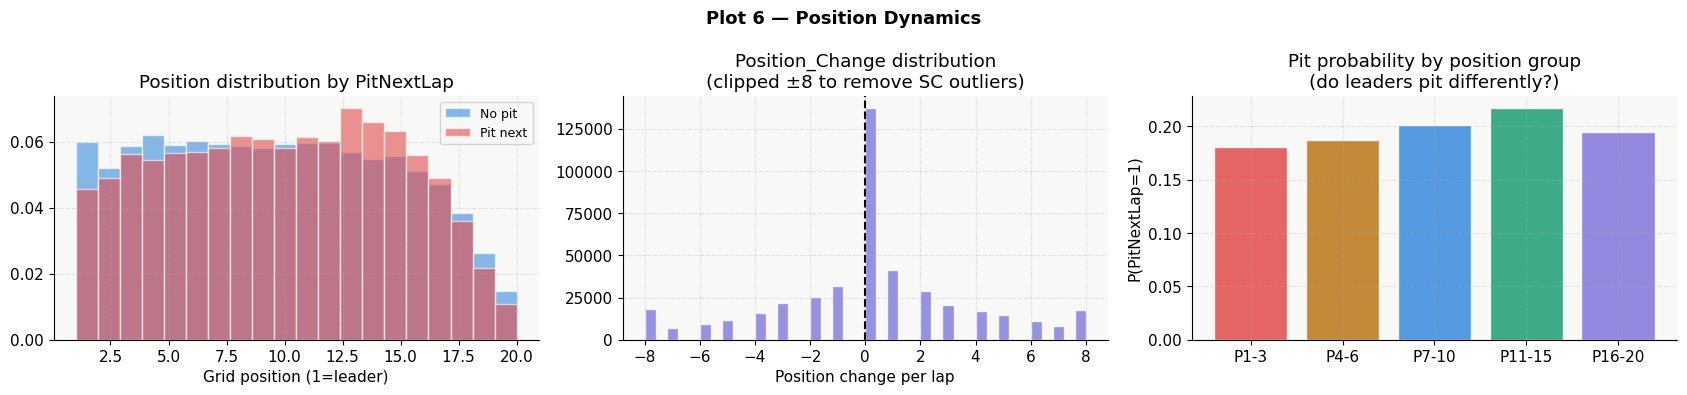

In [18]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  PLOT 6 — Position dynamics over the race                   ║
# ╚══════════════════════════════════════════════════════════════╝
"""
WHY:
  Position and Position_Change capture race dynamics that
  affect pit strategy. A driver in clean air (leading) pits
  differently from a driver in traffic.
  Position_Change mean=0.101 with std=4.0 → mostly stable
  but with occasional large position swings (incidents, SC).

WHAT TO LOOK FOR:
  - Median position steady → processional race (strategy-driven)
  - High variance in Position_Change → chaotic race (reactive pits)
  - Does pit probability differ by Position?
    Leaders → undercut strategy → pit earlier
    Backmarkers → less pressure → strategic/late pit
  - Extreme Position_Change values (±10) → safety car periods,
    these laps should potentially be flagged separately

WHAT TO DO AFTER:
  → Create: train_df['in_top5'] = (train_df['Position'] <= 5).astype(int)
  → Create: train_df['big_position_swing'] = (train_df['Position_Change'].abs() > 5).astype(int)
  → These flag safety car laps which heavily influence pit decisions
"""
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('Plot 6 — Position Dynamics', fontsize=13, fontweight='bold')

# Position distribution by pit/no-pit
for val, lbl, color in [(0, 'No pit', C_BLUE), (1, 'Pit next', C_RED)]:
    axes[0].hist(train_df[train_df[TARGET] == val]['Position'],
                 bins=20, alpha=0.6, label=lbl,
                 color=color, density=True, edgecolor='white')
axes[0].set_title('Position distribution by PitNextLap')
axes[0].set_xlabel('Grid position (1=leader)')
axes[0].legend(fontsize=9)

# Position_Change — clip to remove SC outliers
pc_clipped = train_df['Position_Change'].clip(-8, 8)
axes[1].hist(pc_clipped, bins=40, color=C_PURPLE, alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_title('Position_Change distribution\n(clipped ±8 to remove SC outliers)')
axes[1].set_xlabel('Position change per lap')

# Pit probability by position group
train_df['pos_group'] = pd.cut(train_df['Position'], bins=[0,3,6,10,15,20],
                         labels=['P1-3','P4-6','P7-10','P11-15','P16-20'])
pit_by_pos = train_df.groupby('pos_group', observed=True)[TARGET].mean()
axes[2].bar(pit_by_pos.index, pit_by_pos.values,
            color=[C_RED, C_AMBER, C_BLUE, C_GREEN, C_PURPLE],
            edgecolor='white', alpha=0.85)
axes[2].set_title('Pit probability by position group\n(do leaders pit differently?)')
axes[2].set_ylabel('P(PitNextLap=1)')

plt.tight_layout()
plt.show()

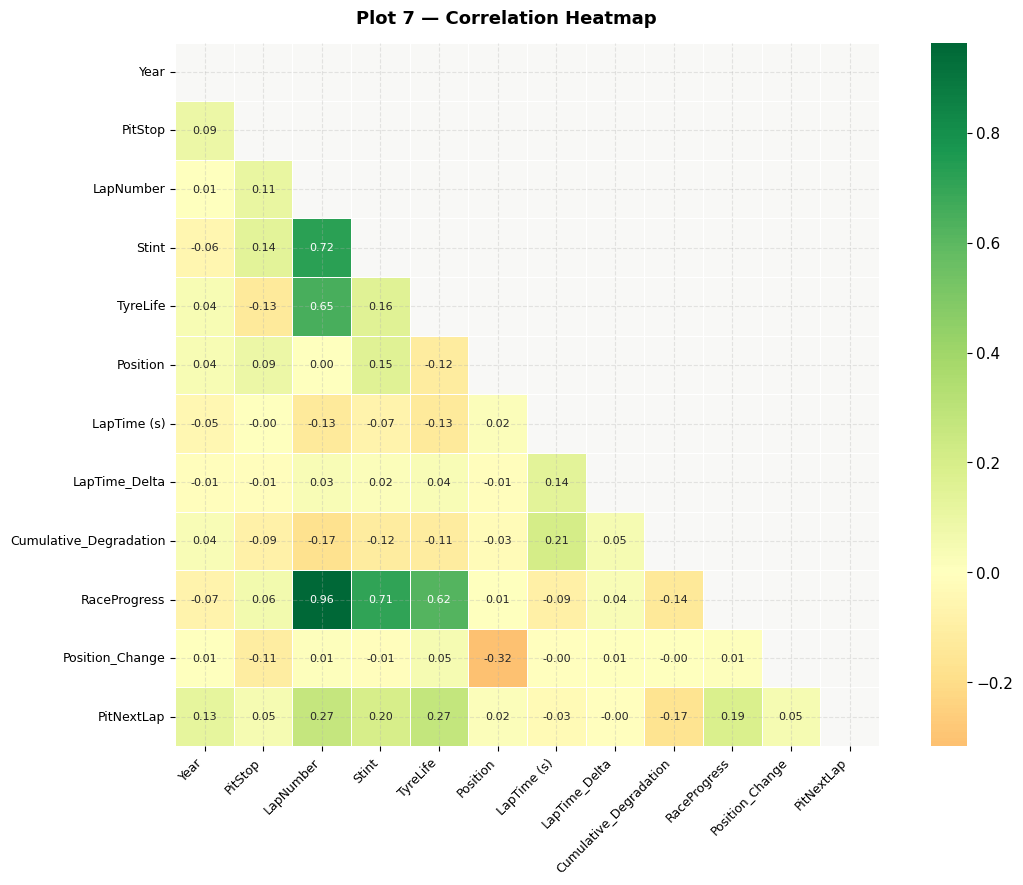

In [19]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  PLOT 7 — Correlation heatmap                               ║
# ╚══════════════════════════════════════════════════════════════╝
"""
WHY:
  Reveals multicollinearity between features — two nearly
  identical features confuse gradient-based models and bloat
  tree models unnecessarily.

WHAT TO LOOK FOR:
  - LapNumber ↔ RaceProgress: almost certainly correlated (>0.95)
    → drop one, they carry the same information
  - TyreLife ↔ Cumulative_Degradation: should be highly correlated
    → check if you really need both
  - LapTime (s) ↔ LapTime_Delta: some correlation but Delta removes
    the circuit baseline → Delta is the cleaner feature
  - Stint ↔ TyreLife: correlated (tyre life resets each stint)
    but not identical

WHAT TO DO AFTER:
  → Drop whichever of (LapNumber, RaceProgress) has lower
    feature importance in Plot 9
  → If Cumulative_Degradation correlates >0.85 with TyreLife,
    drop Cumulative_Degradation (TyreLife is more interpretable)
"""
train_df_enc = train_df[NUMERIC + [TARGET]].copy()
corr   = train_df_enc.corr()

fig, ax = plt.subplots(figsize=(12, 9))
fig.suptitle('Plot 7 — Correlation Heatmap', fontsize=13, fontweight='bold')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

In [20]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  PLOT 8 — Missing value analysis                            ║
# ╚══════════════════════════════════════════════════════════════╝
"""
WHY:
  With 439k rows, even 1% missing is 4,390 rows.
  In time-series lap data, missing is rarely random —
  it often means a DNF, red flag, or data dropout,
  which is meaningful for the model.

WHAT TO LOOK FOR:
  - Missing in LapTime for a specific LapNumber → DNF laps
  - Missing in TyreLife → compound data not recorded (common)
  - Consecutive missing rows for same driver → retirement
  - If missing < 1% total → safe to forward-fill (ffill)
    since lap data is sequential

WHAT TO DO AFTER:
  → train_df.fillna(method='ffill') for sequential lap data
  → Add: train_df['data_dropout'] = train_df[col].isnull().astype(int)
    for any column missing > 2% (missingness is a signal)
  → Never median-impute lap time — a missing lap means
    something happened, not an average lap
"""
missing_pct = (train_df.isnull().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

if len(missing_pct) == 0:
    print("\n✓ No missing values found — clean dataset.")
else:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_pct)*0.5)))
    colors = ['#E24B4A' if p > 20 else '#BA7517' if p > 5 else '#1D9E75'
              for p in missing_pct]
    ax.barh(missing_pct.index, missing_pct.values, color=colors, edgecolor='white')
    ax.axvline(20, color=C_RED, linestyle='--', alpha=0.7, label='20%')
    ax.axvline(5,  color=C_AMBER, linestyle='--', alpha=0.7, label='5%')
    ax.set_xlabel('% Missing')
    ax.legend()
    ax.set_title('Plot 8 — Missing Value Analysis', fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\n── Missing value summary ──")
print(missing_pct.to_string() if len(missing_pct) > 0 else "  None found.")


✓ No missing values found — clean dataset.

── Missing value summary ──
  None found.


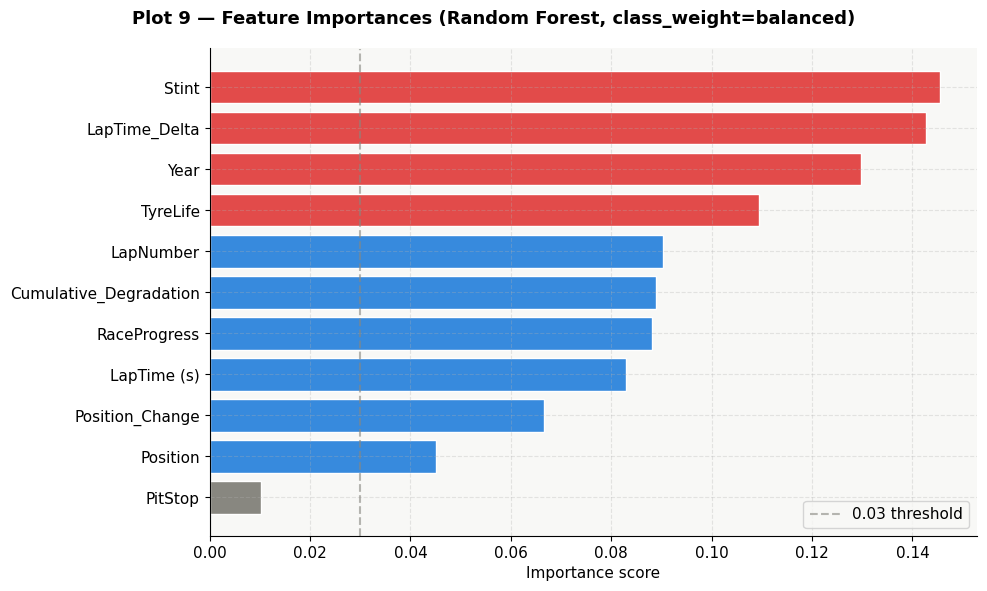


── Feature importances (descending) ──
Stint                     0.145576
LapTime_Delta             0.142684
Year                      0.129834
TyreLife                  0.109469
LapNumber                 0.090381
Cumulative_Degradation    0.088857
RaceProgress              0.088212
LapTime (s)               0.082892
Position_Change           0.066674
Position                  0.045171
PitStop                   0.010249


In [21]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  PLOT 9 — Feature importance (Random Forest)                ║
# ╚══════════════════════════════════════════════════════════════╝
"""
WHY:
  Gives a data-driven ranking of all features in ~1 minute.
  Confirms or challenges your domain assumptions about what
  drives pit stop decisions.

WHAT TO LOOK FOR:
  - TyreLife and RaceProgress should rank very high
    (domain: tyres wear out, strategy windows are race-stage driven)
  - If LapTime_Delta ranks high → degradation signal is in the data
  - If Year ranks high → model might be overfitting to specific
    seasons; consider dropping or using only recent years
  - PitStop should NOT be a feature (it's the same lap as pitting,
    not a predictor of next-lap pitting — that is target leakage)
  - Cumulative_Degradation and TyreLife both high → they carry
    overlapping information, consider dropping one

WHAT TO DO AFTER:
  → Drop features with importance < 0.01
  → Investigate any unexpected top feature for data leakage
  → Use SHAP (Plot 10) to understand direction of influence
"""
train_df_rf = train_df[NUMERIC + [TARGET]].copy()
train_df_rf  = train_df_rf.fillna(train_df_rf.median(numeric_only=True))

# Sample for speed (model still representative on 100k rows)
sample = train_df_rf.sample(min(100_000, len(train_df_rf)), random_state=42)
X = sample.drop(columns=[TARGET])
y = sample[TARGET]

rf = RandomForestClassifier(n_estimators=100, random_state=42,
                             class_weight='balanced', n_jobs=-1)
rf.fit(X, y)

fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Plot 9 — Feature Importances (Random Forest, class_weight=balanced)',
             fontsize=13, fontweight='bold')
colors = [C_RED if v > 0.1 else C_BLUE if v > 0.03 else '#888780' for v in fi.values]
ax.barh(fi.index, fi.values, color=colors, edgecolor='white')
ax.axvline(0.03, color='#888780', linestyle='--', alpha=0.6, label='0.03 threshold')
ax.set_xlabel('Importance score')
ax.legend()
plt.tight_layout()
plt.show()

print("\n── Feature importances (descending) ──")
print(fi.sort_values(ascending=False).to_string())

In [22]:
# # ╔══════════════════════════════════════════════════════════════╗
# # ║  PLOT 10 — SHAP values (post-model explainability)          ║
# # ╚══════════════════════════════════════════════════════════════╝
# """
# WHY:
#   Feature importance tells you WHICH features matter.
#   SHAP tells you HOW they matter — direction and magnitude.
#   Critical for an F1 strategy model where you need to trust
#   predictions and explain them to engineers.

# WHAT TO LOOK FOR:
#   - TyreLife: high values (red dots) should push prediction RIGHT
#     (toward pit=1) — old tyres → pit soon
#   - RaceProgress: should show a complex pattern (not monotonic)
#     reflecting strategic windows in the race
#   - LapTime_Delta positive (getting slower) → pushes toward pit
#   - Cumulative_Degradation: direction should match domain logic
#   - Any feature where high AND low values both push the same way
#     → the model has learned a non-linear interaction

# WHAT TO DO AFTER:
#   → If a feature's SHAP pattern contradicts domain knowledge →
#     investigate for leakage or data quality issues
#   → Use SHAP interaction values for top-2 feature pairs
# """
# import shap

# explainer   = shap.TreeExplainer(rf)
# sample_shap = X.sample(5000, random_state=42)
# shap_values = explainer.shap_values(sample_shap)

# # For binary classification shap_values is list [class0, class1]
# # We want class 1 (pit=1)
# plt.figure(figsize=(10, 7))
# shap.summary_plot(shap_values[1], sample_shap, plot_type='dot',
#                   show=False, max_display=12)
# plt.title('Plot 10 — SHAP Summary (class: PitNextLap=1)',
#           fontsize=12, fontweight='bold')
# plt.tight_layout()
# plt.show()

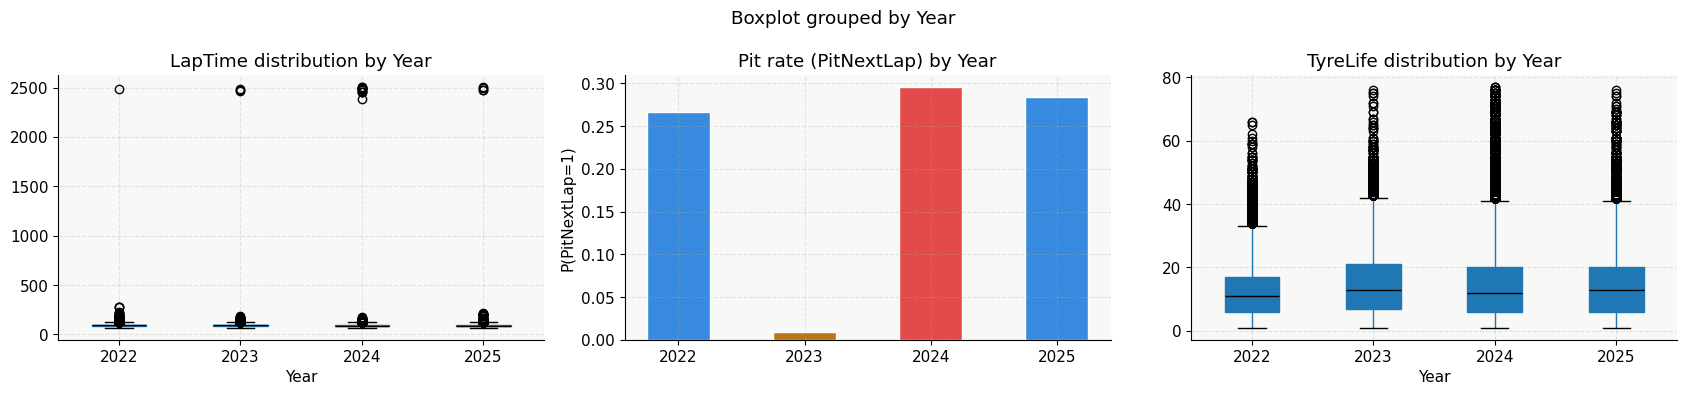

In [26]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  PLOT 11 — Year-level patterns (data drift check)           ║
# ╚══════════════════════════════════════════════════════════════╝
"""
WHY:
  The dataset spans multiple years (mean Year=2023.5).
  F1 regulations, tyre compounds, and race formats change yearly.
  If lap time distributions shift year-over-year, a model trained
  on 2022 will underperform on 2024 — this is data drift.

WHAT TO LOOK FOR:
  - Median LapTime changing year to year → circuit calendar mix
    or regulation change (normal, not a bug)
  - Pit rate changing year to year → rule changes (sprint races
    in 2023+ add artificial pit patterns — be careful)
  - TyreLife patterns shifting → compound allocation changes
  - If 2024 data is very sparse → model will underfit that year

WHAT TO DO AFTER:
  → If drift is severe: train only on most recent 2 years
  → Add Year as a feature so model can calibrate per season
  → Or use time-aware cross-validation:
    train on 2022-2023, validate on 2024 (no future leakage)
"""
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('Plot 11 — Year-Level Data Drift Check', fontsize=13, fontweight='bold')

# LapTime by year
train_df.boxplot(column='LapTime (s)', by='Year', ax=axes[0],
           patch_artist=True, medianprops=dict(color='black'))
axes[0].set_title('LapTime distribution by Year')
axes[0].set_xlabel('Year')

# Pit rate by year
pit_yr = train_df.groupby('Year')[TARGET].mean()
axes[1].bar(pit_yr.index.astype(str), pit_yr.values,
            color=[C_BLUE, C_AMBER, C_RED][:len(pit_yr)],
            width=0.5, edgecolor='white')
axes[1].set_title('Pit rate (PitNextLap) by Year')
axes[1].set_ylabel('P(PitNextLap=1)')

# TyreLife by year
train_df.boxplot(column='TyreLife', by='Year', ax=axes[2],
           patch_artist=True, medianprops=dict(color='black'))
axes[2].set_title('TyreLife distribution by Year')
axes[2].set_xlabel('Year')

plt.tight_layout()
plt.show()

In [27]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  FULL EDA SUMMARY + RECOMMENDED NEXT STEPS                  ║
# ╚══════════════════════════════════════════════════════════════╝
print("\n" + "="*65)
print("  F1 EDA COMPLETE — RECOMMENDED NEXT STEPS")
print("="*65)

print("""
FEATURE ENGINEERING (based on what EDA will show):
  df['TyreLife_sq']       = df['TyreLife'] ** 2
  df['TyreLife_log']      = np.log1p(df['TyreLife'])
  df['in_top5']           = (df['Position'] <= 5).astype(int)
  df['tyre_critical']     = (df['TyreLife'] > 25).astype(int)
  df['big_swing']         = (df['Position_Change'].abs() > 5).astype(int)
  df['pit_window_early']  = df['RaceProgress'].between(0.25, 0.45)
  df['pit_window_late']   = df['RaceProgress'].between(0.55, 0.72)

LIKELY DROPS (check correlation plot first):
  → Drop 'LapNumber' if corr(LapNumber, RaceProgress) > 0.9
  → Drop 'Cumulative_Degradation' if corr with TyreLife > 0.85
  → Never use 'PitStop' as a feature (same-lap leakage)

MODEL CHOICE:
  → LightGBM with scale_pos_weight=4 (handles imbalance + NaN)
  → Time-aware CV: train on earlier years, validate on latest

METRICS TO USE (NOT accuracy):
  → ROC-AUC  (overall ranking quality)
  → PR-AUC   (best for imbalanced binary classification)
  → F1-score (macro) at optimized threshold from PR curve

DECISION THRESHOLD:
  from sklearn.metrics import precision_recall_curve
  precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
  # Pick threshold where F1 is maximized, not default 0.5
""")
print("="*65)


  F1 EDA COMPLETE — RECOMMENDED NEXT STEPS

FEATURE ENGINEERING (based on what EDA will show):
  df['TyreLife_sq']       = df['TyreLife'] ** 2
  df['TyreLife_log']      = np.log1p(df['TyreLife'])
  df['in_top5']           = (df['Position'] <= 5).astype(int)
  df['tyre_critical']     = (df['TyreLife'] > 25).astype(int)
  df['big_swing']         = (df['Position_Change'].abs() > 5).astype(int)
  df['pit_window_early']  = df['RaceProgress'].between(0.25, 0.45)
  df['pit_window_late']   = df['RaceProgress'].between(0.55, 0.72)

LIKELY DROPS (check correlation plot first):
  → Drop 'LapNumber' if corr(LapNumber, RaceProgress) > 0.9
  → Drop 'Cumulative_Degradation' if corr with TyreLife > 0.85
  → Never use 'PitStop' as a feature (same-lap leakage)

MODEL CHOICE:
  → LightGBM with scale_pos_weight=4 (handles imbalance + NaN)
  → Time-aware CV: train on earlier years, validate on latest

METRICS TO USE (NOT accuracy):
  → ROC-AUC  (overall ranking quality)
  → PR-AUC   (best for imbalanced b

# Feature Engineering

### Finding the different columns

In [29]:
num_cols = train_df.select_dtypes(include='number').columns.tolist()
for i in ['id', 'PitNextLap']:
    num_cols.remove(i)
cat_cols = train_df.select_dtypes(include='object').columns.tolist()

print(f'Numeric columns: {num_cols}\nCategorical columns: {cat_cols}')

Numeric columns: ['Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change']
Categorical columns: ['Driver', 'Compound', 'Race']


## Scaling Dataset

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler().fit(train_df[train_num_cols])

In [ ]:
train_df[train_num_cols] = scaler.transform(train_df[train_num_cols])
test_df[test_num_cols] = scaler.transform(test_df[test_num_cols])

In [ ]:
train_df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,...,Organic_Carbon_X_Field_Area_hectare,Wind_X_SoilMoisture,OrgCarbon_X_SoilpH,Rain_per_SunHour,Humidity_per_Temp,SoilMoist_per_Temp,ET_proxy,High_Irrigation_Need,Low_Irrigation_Need,Medium_Irrigation_Need
0,Loamy,0.035294,0.431304,0.546154,0.867647,0.100333,0.365909,0.290324,0.271429,0.835385,...,0.302865,0.419817,0.302865,0.211003,0.384274,0.384781,0.097920,0.002394,0.292837,0.288867
1,Clay,0.670588,0.852957,0.107692,0.558824,0.364000,0.612373,0.394221,0.425714,0.148205,...,0.143354,0.145270,0.143354,0.247721,0.335902,0.453830,0.270693,0.000931,0.403926,0.400393
2,Clay,0.261765,0.345850,0.392308,0.802941,0.499000,0.960423,0.880771,0.292857,0.171795,...,0.271866,0.079380,0.271866,0.626499,0.404559,0.167370,0.278402,0.000269,0.868776,0.867834
3,Sandy,0.250000,0.093350,0.792308,0.226471,0.044000,0.522503,0.542930,0.731429,0.092821,...,0.521853,0.020688,0.521853,0.269004,0.554136,0.154767,0.177552,0.000239,0.532510,0.529623
4,Clay,0.929412,0.897350,0.061538,0.252941,0.274000,0.944564,0.615298,0.421429,0.689231,...,0.135576,0.634278,0.135576,0.388108,0.553242,0.541346,0.223636,0.001695,0.621276,0.619103


In [ ]:
test_df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,...,Organic_Carbon_X_Field_Area_hectare,Wind_X_SoilMoisture,OrgCarbon_X_SoilpH,Rain_per_SunHour,Humidity_per_Temp,SoilMoist_per_Temp,ET_proxy,High_Irrigation_Need,Low_Irrigation_Need,Medium_Irrigation_Need
0,Silt,0.458824,0.319179,0.223077,0.797059,0.194333,0.074868,0.613369,0.200000,0.128205,...,0.198176,0.057645,0.198176,0.480617,0.152226,0.250681,0.116602,0.000245,0.606486,0.604026
1,Clay,0.314706,0.032988,0.676923,0.929412,0.306000,0.758251,0.230332,0.460000,0.788718,...,0.471272,0.118200,0.471272,0.140503,0.437792,0.053851,0.253609,0.001440,0.225236,0.220743
2,Sandy,0.417647,0.325496,0.507692,0.220588,0.495667,0.505072,0.218028,0.775714,0.109231,...,0.389073,0.050885,0.389073,0.104794,0.235702,0.159445,0.496635,0.001595,0.219723,0.215219
3,Clay,0.847059,0.799789,0.407692,0.132353,0.991333,0.157880,0.484394,0.384286,0.069744,...,0.423763,0.073949,0.423763,0.315870,0.038459,0.222109,0.559183,0.000806,0.490988,0.487940
4,Loamy,0.126471,0.895245,0.184615,0.591176,0.969333,0.392485,0.528758,0.015714,0.267179,...,0.118317,0.257448,0.118317,0.518940,0.098655,0.253117,0.292118,0.001003,0.536536,0.533778


## Imputing the Categorical Columns

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(train_df[train_cat_cols])

In [ ]:
encoded_cols = encoder.get_feature_names_out().tolist()
encoded_cols, type(encoded_cols)

(['Soil_Type_Clay',
  'Soil_Type_Loamy',
  'Soil_Type_Sandy',
  'Soil_Type_Silt',
  'Crop_Type_Cotton',
  'Crop_Type_Maize',
  'Crop_Type_Potato',
  'Crop_Type_Rice',
  'Crop_Type_Sugarcane',
  'Crop_Type_Wheat',
  'Crop_Growth_Stage_Flowering',
  'Crop_Growth_Stage_Harvest',
  'Crop_Growth_Stage_Sowing',
  'Crop_Growth_Stage_Vegetative',
  'Season_Kharif',
  'Season_Rabi',
  'Season_Zaid',
  'Irrigation_Type_Canal',
  'Irrigation_Type_Drip',
  'Irrigation_Type_Rainfed',
  'Irrigation_Type_Sprinkler',
  'Water_Source_Groundwater',
  'Water_Source_Rainwater',
  'Water_Source_Reservoir',
  'Water_Source_River',
  'Mulching_Used_No',
  'Mulching_Used_Yes',
  'Region_Central',
  'Region_East',
  'Region_North',
  'Region_South',
  'Region_West'],
 list)

In [ ]:
train_df[encoded_cols] = encoder.transform(train_df[train_cat_cols])
test_df[encoded_cols] = encoder.transform(test_df[test_cat_cols])

In [ ]:
train_df.columns, test_df.columns

(Index(['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
        'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
        'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
        'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
        'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need',
        'Total_Irrigation_Need', 'Irrigation_Need_Std', 'Irrigation_Need_Mean',
        'Irrigation_Need_Median', 'Irrigation_Need_Min', 'Irrigation_Need_Max',
        'Irrigation_Need_Skew', 'Irrigation_Need_Kurtosis',
        'Irrigation_Need_CV', 'Irrigation_Need_25', 'Irrigation_Need_75',
        'Irrigation_Need_IQR', 'Weather_effects_loss', 'Weather_effects_gain',
        'Soil_effects', 'Human_effects', 'Net_Weather_Stress',
        'Soil_Moisture_X_Temperature', 'Humidity_X_Rainfall_mm',
        'Soil_Moisture_D_Sunlight_Hours', 'Sunlight_Hours_X_Temperature',
        'Field_Area_hectare_X_Previous_Irrigat

In [ ]:
for col in train_df.columns:
    print(f'{col}: {train_df[col].dtype}')

Soil_Type: object
Soil_pH: float64
Soil_Moisture: float64
Organic_Carbon: float64
Electrical_Conductivity: float64
Temperature_C: float64
Humidity: float64
Rainfall_mm: float64
Sunlight_Hours: float64
Wind_Speed_kmh: float64
Crop_Type: object
Crop_Growth_Stage: object
Season: object
Irrigation_Type: object
Water_Source: object
Field_Area_hectare: float64
Mulching_Used: object
Previous_Irrigation_mm: float64
Region: object
Irrigation_Need: int64
Total_Irrigation_Need: float64
Irrigation_Need_Std: float64
Irrigation_Need_Mean: float64
Irrigation_Need_Median: float64
Irrigation_Need_Min: float64
Irrigation_Need_Max: float64
Irrigation_Need_Skew: float64
Irrigation_Need_Kurtosis: float64
Irrigation_Need_CV: float64
Irrigation_Need_25: float64
Irrigation_Need_75: float64
Irrigation_Need_IQR: float64
Weather_effects_loss: float64
Weather_effects_gain: float64
Soil_effects: float64
Human_effects: float64
Net_Weather_Stress: float64
Soil_Moisture_X_Temperature: float64
Humidity_X_Rainfall_mm: 

### Final training and test datasets

In [ ]:
input_cols = train_num_cols + encoded_cols
target_col = 'Irrigation_Need'

In [ ]:
input_df = train_df[train_num_cols + encoded_cols]
test_df = test_df[test_num_cols + encoded_cols]

In [ ]:
input_df.columns, test_df.columns

(Index(['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
        'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
        'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm',
        'Total_Irrigation_Need', 'Irrigation_Need_Std', 'Irrigation_Need_Mean',
        'Irrigation_Need_Median', 'Irrigation_Need_Min', 'Irrigation_Need_Max',
        'Irrigation_Need_Skew', 'Irrigation_Need_Kurtosis',
        'Irrigation_Need_CV', 'Irrigation_Need_25', 'Irrigation_Need_75',
        'Irrigation_Need_IQR', 'Weather_effects_loss', 'Weather_effects_gain',
        'Soil_effects', 'Human_effects', 'Net_Weather_Stress',
        'Soil_Moisture_X_Temperature', 'Humidity_X_Rainfall_mm',
        'Soil_Moisture_D_Sunlight_Hours', 'Sunlight_Hours_X_Temperature',
        'Field_Area_hectare_X_Previous_Irrigation_mm',
        'Wind_Speed_kmh_X_Temperature_C', 'Organic_Carbon_X_Field_Area_hectare',
        'Wind_X_SoilMoisture', 'OrgCarbon_X_SoilpH', 'Rain_per_S

In [ ]:
test_df.size

20520000

## Train/Val Split and Test Input and Target

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val , Y_train, Y_val = train_test_split(input_df[input_cols],
                                                   train_df[target_col],
                                                   test_size=0.2,
                                                   random_state=231)

## Training Models

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
def get_accuracy(Y_train, Y_val, train_pred, val_pred):
    train_acc = accuracy_score(Y_train, train_pred)
    val_acc = accuracy_score(Y_val, val_pred)

    train_prec = precision_score(Y_train, train_pred, average='weighted')
    val_prec = precision_score(Y_val, val_pred, average='weighted')

    train_rec = recall_score(Y_train, train_pred, average='weighted')
    val_rec = recall_score(Y_val, val_pred, average='weighted')

    train_f1 = f1_score(Y_train, train_pred, average='weighted')
    val_f1 = f1_score(Y_val, val_pred, average='weighted')

    print(f'Train accuracy score: {train_acc}')
    print(f'Val accuracy score: {val_acc}\n')

    print(f'Train precision score: {train_prec}')
    print(f'val precision score: {val_prec}\n')

    print(f'Train recall score: {train_rec}')
    print(f'val recall score: {val_rec}\n')

    print(f'Train f1 score: {train_f1}')
    print(f'val f1 score: {val_f1}\n')

### LightGBM Model

In [ ]:
import lightgbm
from lightgbm import early_stopping, log_evaluation

In [ ]:
lgbm_params = {
    'n_estimators': 2500,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.6,
    'random_state': 523,
    'n_jobs': -1
}

lgbm = lightgbm.LGBMClassifier(**lgbm_params)

In [ ]:
lgbm.fit(X_train, Y_train,
         eval_set=[(X_val, Y_val)],
         callbacks=[
            early_stopping(stopping_rounds=100,),
            log_evaluation(period=50)
        ])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.132577 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11046
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 76
[LightGBM] [Info] Start training from score -0.532018
[LightGBM] [Info] Start training from score -0.969633
[LightGBM] [Info] Start training from score -3.400424
Training until validation scores don't improve for 100 rounds
[50]	valid_0's multi_logloss: 0.103497
[100]	valid_0's multi_logloss: 0.0680264
[150]	valid_0's multi_logloss: 0.0627271
[200]	valid_0's multi_logloss: 0.0607292
[250]	valid_0's multi_logloss: 0.0595594
[300]	valid_0's multi_logloss: 0.0589756
[350]	valid_0's multi_logloss: 0.0584801
[400]	valid_0's multi_logloss: 0.0581662
[450]	valid_0's multi_logloss: 0.0579513
[500]	valid_0's multi_logloss: 0.0577638
[550]	valid_0's multi_logloss: 0.0576782
[600]	valid_0's multi_logloss: 0.057

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,2500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
train_pred = lgbm.predict(X_train)
val_pred = lgbm.predict(X_val)

In [ ]:
get_accuracy(Y_train, Y_val, train_pred, val_pred)

Train accuracy score: 0.9892460317460318
Val accuracy score: 0.9847777777777778

Train precision score: 0.9892663282683305
val precision score: 0.9847368801660104

Train recall score: 0.9892460317460318
val recall score: 0.9847777777777778

Train f1 score: 0.9892292649809823
val f1 score: 0.9847074738026208



In [ ]:
sdsd

In [ ]:
sdfs

# XGBoost

In [ ]:
import xgboost

In [ ]:
xgb_params = {
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'max_depth': 7,
    'min_child_weight': 3,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0.1,
    'n_jobs': -1
}
xgbc = xgboost.XGBClassifier(**xgb_params)

In [ ]:
xgbc.fit(X_train, Y_train, 
        eval_set=[(X_val, Y_val)],
        verbose=100)

[0]	validation_0-mlogloss:0.90986


KeyboardInterrupt: 

In [ ]:
train_pred = xgbc.predict(X_train)
val_pred = xgbc.predict(X_val)

In [ ]:
get_accuracy(Y_train, Y_val, train_pred, val_pred)

Train accuracy score: 0.9937242063492063
Val accuracy score: 0.9842063492063492

Train precision score: 0.9937342039078549
val precision score: 0.9841623311125799

Train recall score: 0.9937242063492063
val recall score: 0.9842063492063492

Train f1 score: 0.993719317593416
val f1 score: 0.9841315746431901



## Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_params = {
    'n_estimators': 200,
    'max_depth': 7,
    'min_samples_split': 7,
    'min_samples_leaf': 4,
    'max_features': 0.8,
    'verbose': 2,
    'n_jobs': -1
    
}
rfc = RandomForestClassifier(**rf_params)

In [ ]:
rfc.fit(X_train, Y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


building tree 1 of 200building tree 2 of 200
building tree 3 of 200
building tree 4 of 200
building tree 5 of 200
building tree 6 of 200
building tree 7 of 200

building tree 8 of 200
building tree 9 of 200
building tree 10 of 200
building tree 11 of 200
building tree 12 of 200
building tree 13 of 200
building tree 14 of 200
building tree 15 of 200
building tree 16 of 200
building tree 17 of 200
building tree 18 of 200
building tree 19 of 200
building tree 20 of 200building tree 21 of 200

building tree 22 of 200
building tree 23 of 200
building tree 24 of 200
building tree 25 of 200
building tree 26 of 200
building tree 27 of 200
building tree 28 of 200
building tree 29 of 200


[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:  1.0min


building tree 30 of 200
building tree 31 of 200
building tree 32 of 200
building tree 33 of 200
building tree 34 of 200
building tree 35 of 200
building tree 36 of 200
building tree 37 of 200
building tree 38 of 200
building tree 39 of 200
building tree 40 of 200
building tree 41 of 200
building tree 42 of 200
building tree 43 of 200
building tree 44 of 200
building tree 45 of 200
building tree 46 of 200
building tree 47 of 200
building tree 48 of 200
building tree 49 of 200
building tree 50 of 200
building tree 51 of 200
building tree 52 of 200
building tree 53 of 200
building tree 54 of 200
building tree 55 of 200
building tree 56 of 200
building tree 57 of 200
building tree 58 of 200
building tree 59 of 200
building tree 60 of 200
building tree 61 of 200
building tree 62 of 200
building tree 63 of 200
building tree 64 of 200
building tree 65 of 200
building tree 66 of 200
building tree 67 of 200
building tree 68 of 200
building tree 69 of 200
building tree 70 of 200
building tree 71

[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed:  6.3min


building tree 151 of 200
building tree 152 of 200
building tree 153 of 200
building tree 154 of 200
building tree 155 of 200
building tree 156 of 200
building tree 157 of 200
building tree 158 of 200
building tree 159 of 200
building tree 160 of 200
building tree 161 of 200
building tree 162 of 200
building tree 163 of 200
building tree 164 of 200
building tree 165 of 200
building tree 166 of 200
building tree 167 of 200
building tree 168 of 200
building tree 169 of 200
building tree 170 of 200
building tree 171 of 200
building tree 172 of 200
building tree 173 of 200
building tree 174 of 200
building tree 175 of 200
building tree 176 of 200
building tree 177 of 200
building tree 178 of 200
building tree 179 of 200
building tree 180 of 200
building tree 181 of 200
building tree 182 of 200
building tree 183 of 200
building tree 184 of 200
building tree 185 of 200
building tree 186 of 200
building tree 187 of 200
building tree 188 of 200
building tree 189 of 200
building tree 190 of 200


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  8.8min finished


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",7
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.8
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tru

In [ ]:
train_pred = rfc.predict(X_train)
val_pred = rfc.predict(X_val)

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.2s
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:    1.3s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    2.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:    0.4s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.5s finished


In [ ]:
get_accuracy(Y_train, Y_val, train_pred, val_pred)

Train accuracy score: 0.9802559523809524
Val accuracy score: 0.979468253968254

Train precision score: 0.980149992959363
val precision score: 0.9793694487588628

Train recall score: 0.9802559523809524
val recall score: 0.979468253968254

Train f1 score: 0.9799832946896965
val f1 score: 0.9791652517127422



## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr_params = {
    'C': 0.1,
    'penalty': 'l2',
    'solver': 'liblinear'
}
lr = LogisticRegression(**lr_params).fit(X_train, Y_train)

c:\Users\itspr\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


ValueError: The 'liblinear' solver does not support multiclass classification (n_classes >= 3). Either use another solver or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.

In [ ]:
train_pred = lr.predict(X_train)
val_pred = lr.predict(X_val)

In [ ]:
get_accuracy(Y_train, Y_val, train_pred, val_pred)

Train accuracy score: 0.8864067460317461
Val accuracy score: 0.8856984126984127

Train precision score: 0.8863116460970124
val precision score: 0.8855928759703007

Train recall score: 0.8864067460317461
val recall score: 0.8856984126984127

Train f1 score: 0.8859920739644549
val f1 score: 0.8853018051959595

